Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print('Done!')

Done!


Load data to pandas

In [2]:
# columns names are not given in first row, so we must write them manually
column_names = ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 
    'marital-status', 'occupation', 'relationship', 'race', 'sex', 
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']
df = pd.read_csv('adult.data', names=column_names, sep=',\s*', engine='python', na_values=['?'])
display(df.head())

<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
C:\Users\38050\AppData\Local\Temp\ipykernel_79784\4205986531.py:5: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv('adult.data', names=column_names, sep=',\s*', engine='python', na_values=['?'])


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


Let`s have a look how many NaN values does we have

In [3]:
df.isna().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64

Now we can start data cleaning. \
First thing we do - fill NaN in workclass, occupation and native-country

In [4]:
def fill_NaN_workclass(row):
    # If data is not NaN - we dont touch it
    if pd.notnull(row['workclass']):
        return row['workclass']
    # If it is NaN we will check values in capital-gain, capital-loss, hours-per-week and fill the NaN with logical guess
    if row['hours-per-week'] == 0: # 0 hours for work = no work
        return 'Never-worked'
    elif row['hours-per-week'] < 10 and row['capital-gain'] == 0: # probably just a minimal work or Old people
        return 'Without-pay'
    elif row['hours-per-week'] == 40 and row['education'] in ['Bachelors', 'Masters', 'Doctorate', 'Prof-school'] and row['capital-gain'] == 0:
        return np.random.choice(['State-gov', 'Local-gov', 'Federal-gov','Private']) # average for goverment work - good education, stable payment and 5*8 hours per week
    elif row['hours-per-week'] > 45 and row['income'] == '>50K': # lots of work + good income = Self-emp-inc
        return 'Self-emp-inc'
    elif row['hours-per-week'] > 45:
        return 'Self-emp-not-inc'
    return 'Private'   # most common value

def fill_NaN_occupation(row):
     # If data is not NaN - we dont touch it
    if pd.notnull(row['occupation']):
        return row['occupation']
    # If it is NaN we will check values in capital-gain, capital-loss, hours-per-week and fill the NaN with logical guess
    if row['hours-per-week'] >= 45 and row['education'] in ['Bachelors', 'Masters', 'Doctorate', 'Prof-school']:
        return np.random.choice(['Exec-managerial', 'Prof-specialty']) # profesionals
    elif row['age'] < 25 or row['hours-per-week'] < 30: # young or low working people
        return np.random.choice(['Other-service', 'Adm-clerical', 'Sales'])
    elif row['workclass'] == 'Private' and row['education-num'] <= 10: # bad education and a default worker
        return np.random.choice(['Craft-repair', 'Machine-op-inspct', 'Transport-moving', 'Handlers-cleaners','Transport-moving'])
    elif row['hours-per-week'] > 30: # totaly random variants
        return np.random.choice(['Craft-repair', 'Machine-op-inspct', 'Transport-moving', 'Handlers-cleaners','Transport-moving','Tech-support', 'Farming-fishing', 'Priv-house-serv'])
    return 'Prof-specialty'

def fill_NaN_country(row):
    # If data is not NaN - we dont touch it
    if pd.notnull(row['native-country']):
        return row['native-country']
    #  If it is NaN we will check values in race and fill the NaN with logical guess
    if row['race'] == 'Asian-Pac-Islander': # Asian race = asian country
        return np.random.choice(['Philippines', 'India', 'China', 'Japan', 'Vietnam', 'Taiwan'])
    elif row['race'] in ['Other', 'Black']:
        return np.random.choice(['Mexico', 'Puerto-Rico', 'Cuba', 'Dominican-Republic', 'Jamaica'])
    elif np.random.rand() > 0.9: # 10% for Europe
        return np.random.choice(['Germany', 'England', 'Canada', 'Italy', 'France', 'Greece', 'Ireland', 'Yugoslavia', 'Hungary'])
    return 'United-States' # 90% of all values

print('Done')

Done


apply our filters to fill all NaN \
data types are already good, so we dont need to fix them

In [5]:
df['workclass'] = df.apply(fill_NaN_workclass, axis=1)
df['occupation'] = df.apply(fill_NaN_occupation, axis=1)
df['native-country'] = df.apply(fill_NaN_country, axis=1)
df.isna().sum()

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

Now we can start making our Plots and graphs
1. Побудувати графіки залежності одного integer/real атрибута від іншого (lineplot, scatter etc).

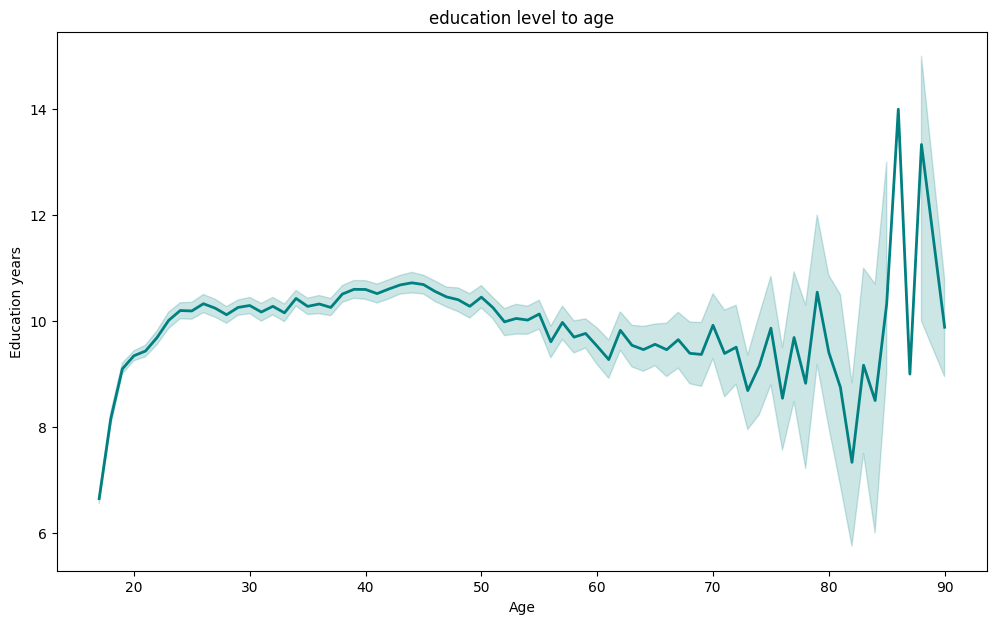

In [6]:
plt.figure(figsize=(12, 7))
sns.lineplot(data=df, x='age', y='education-num', color='teal', linewidth=2)
plt.title('education level to age')
plt.xlabel('Age')
plt.ylabel('Education years')
plt.show()
# From this plot we can see that education level greatly upgrades till 25 years, then we have little enchancement till 45 years, where education
# starts to descend a bit. After 75-80 years the graph is very unstable, probably due to small sample of this age in our DF.

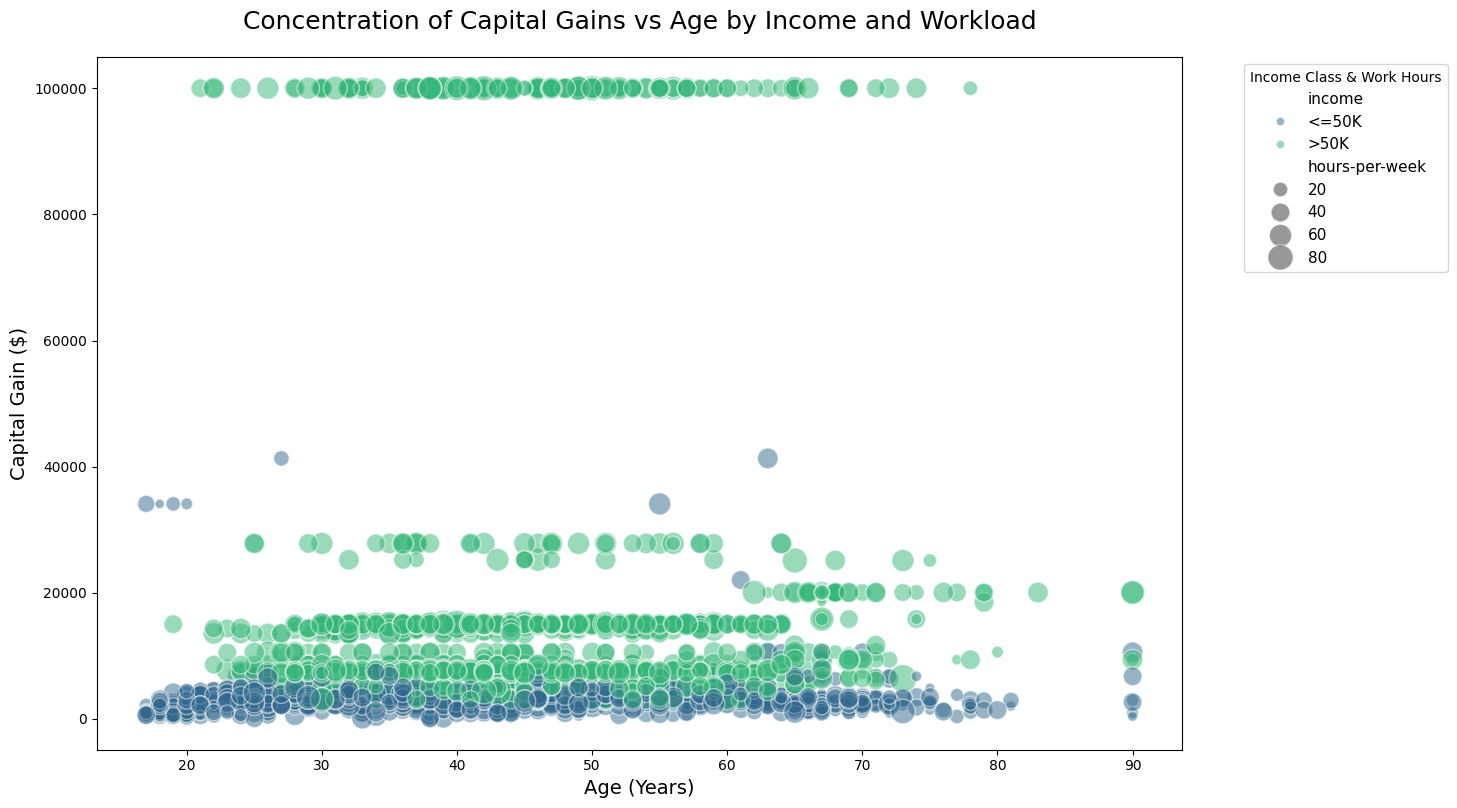

In [7]:
df_gain = df[df['capital-gain'] > 0].copy()
plt.figure(figsize=(14, 9))
sns.scatterplot(data=df_gain, x='age', y='capital-gain', hue='income', size='hours-per-week',sizes=(40, 400),alpha=0.5, palette='viridis')
plt.title('Concentration of Capital Gains vs Age by Income and Workload', fontsize=18, pad=20)
plt.xlabel('Age (Years)', fontsize=14)
plt.ylabel('Capital Gain ($)', fontsize=14)
plt.legend(title='Income Class & Work Hours', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)
plt.show()
# From this plot we can see that Individual can save some money (increase his capital) only if it has income >50K, but somehow there 
# are some dots where capital gain is more than income (maybe investitions). Also we have a very big free space between 30K capital gain and 100K

2. Побудувати гістограму по одному з атрибутів, що буде показувати на кількість елементів, що знаходяться у 5 діапазонах, які ви задасте.

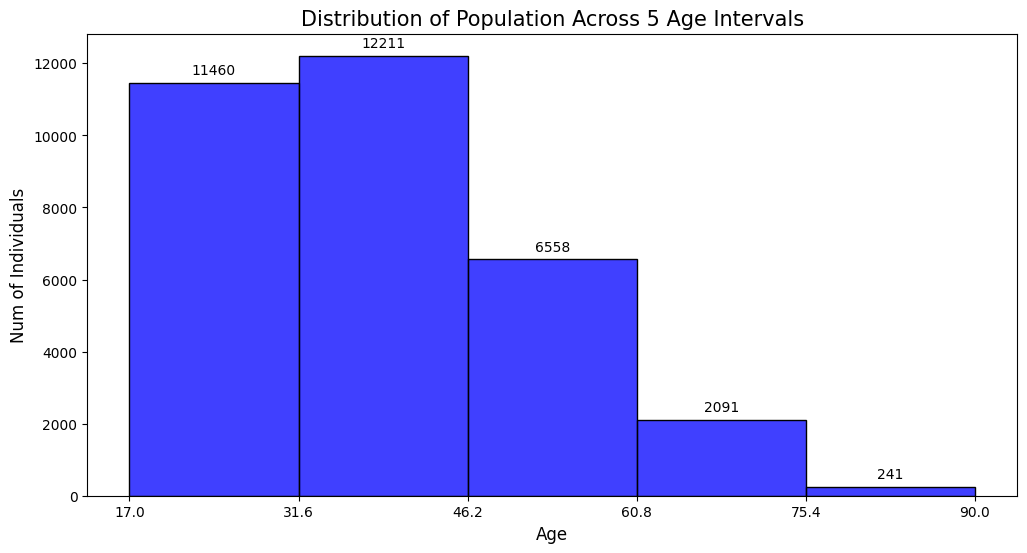

In [8]:
age_bins = np.linspace(df['age'].min(), df['age'].max(), 6) # split our age into 5 same intervals
plt.figure(figsize=(12, 6))
ax = sns.histplot(df['age'], bins=age_bins, color='blue', edgecolor='black')
for p in ax.patches: # make numbers above columns
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), ha = 'center', va = 'center', xytext = (0, 9), textcoords = 'offset points')
plt.title('Distribution of Population Across 5 Age Intervals', fontsize=15)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Num of Individuals', fontsize=12)
plt.xticks(age_bins)
plt.show()
# This gistogramm is like a demographic pyramid

3. Збудувати графіки, використовуючи приклади, наведені у https://medium.com/data-science/the-art-of-effective-visualization-of-multi-dimensional-data-6c7202990c57 

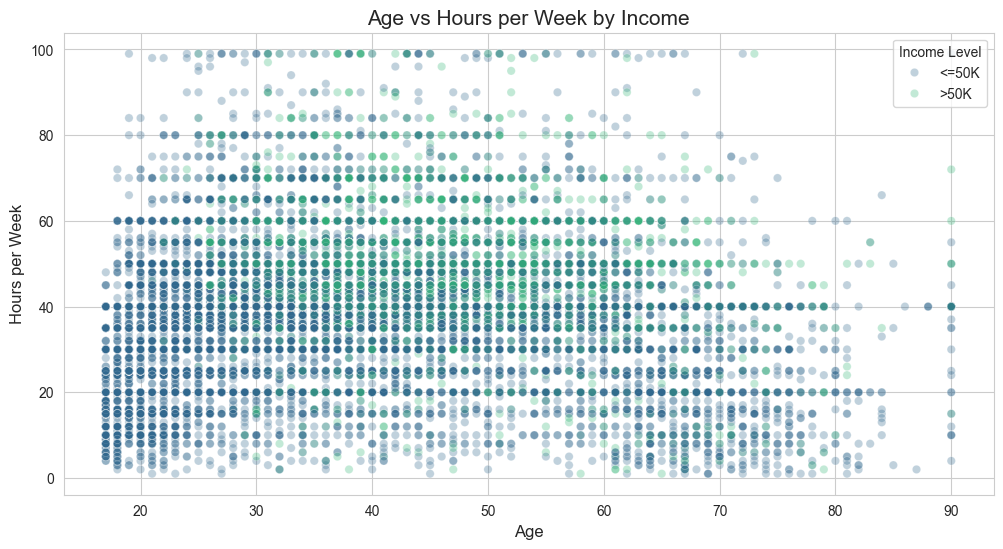

In [13]:
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
sns.scatterplot(data=df,x='age', y='hours-per-week', hue='income', palette='viridis', alpha=0.3)
plt.title('Age vs Hours per Week by Income', fontsize=15)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Hours per Week', fontsize=12)
plt.legend(title='Income Level', loc='upper right')
plt.show()
# From this plot we can see that working hours usually increases from 17 to 25 years (from avg 10h to 40h) then doesnt change a lot till 50-55 years -
# the age where Individuals start getting retired. Also, as we can see, more time at work doesnt mean more Income.

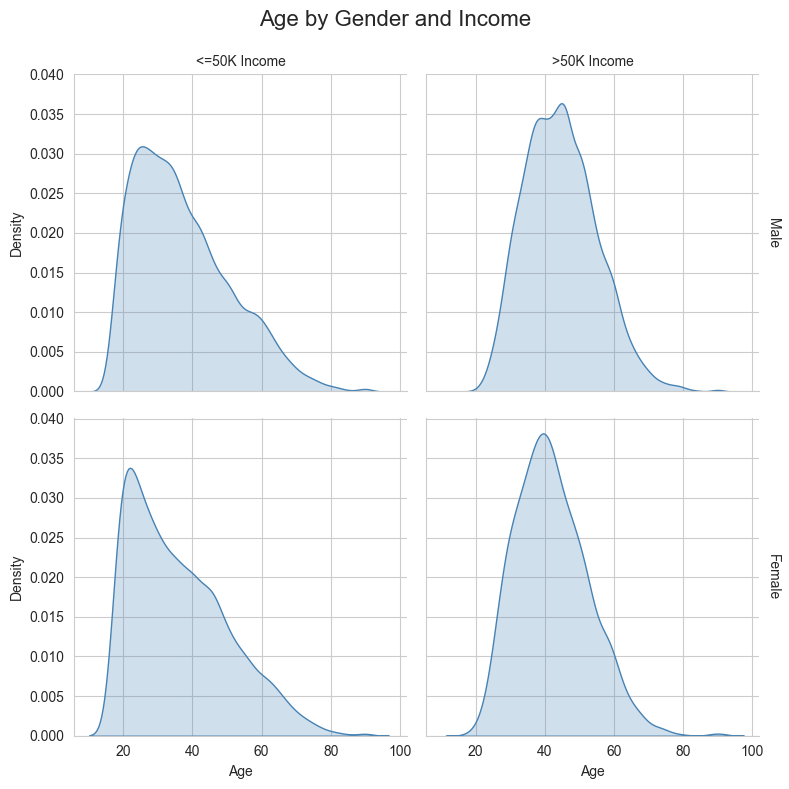

In [10]:
g = sns.FacetGrid(df, col="income", row="sex", margin_titles=True, height=4)
g.map(sns.kdeplot, "age", color="steelblue", fill=True)

g.set_axis_labels("Age", "Density")
g.set_titles(col_template="{col_name} Income", row_template="{row_name}")
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle('Age by Gender and Income', fontsize=16)
plt.show()
# From this plot we can see the normal tendention - most of people with age ~25 have income <=50K and in age of ~40 income >50K.
# There is also a small difference between  Male and Female, but it is too small to say something about it

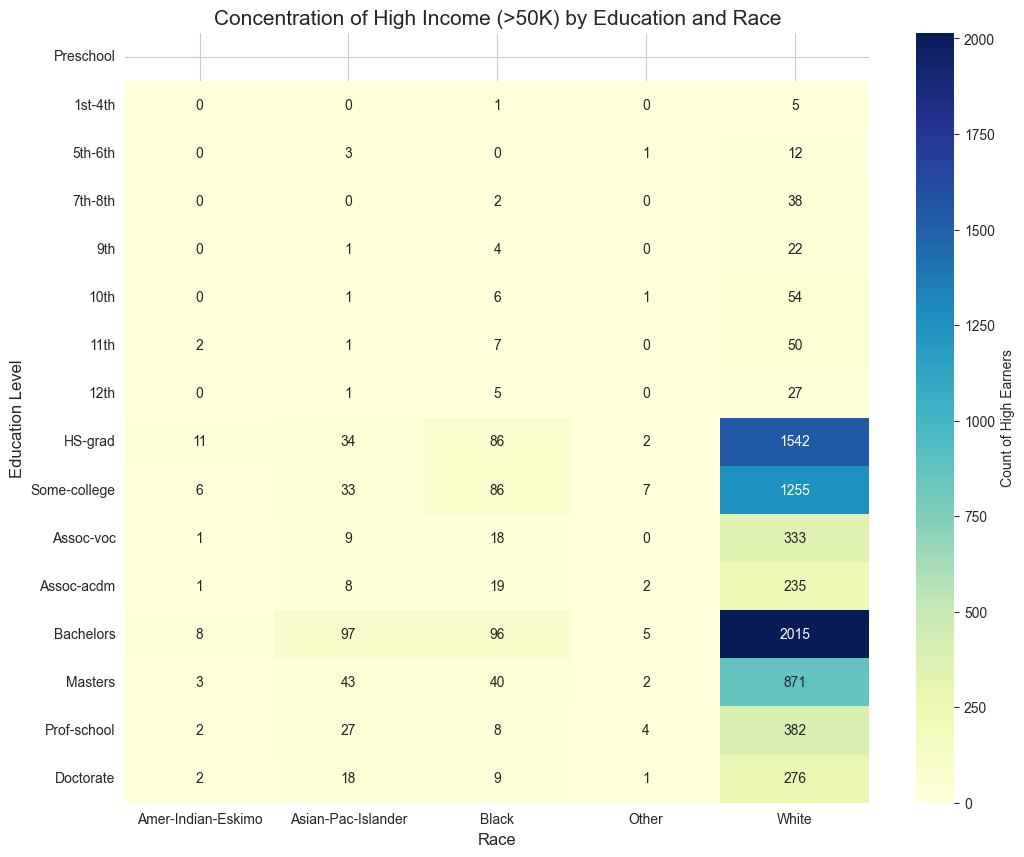

In [11]:
high_inc = df[df['income'] == '>50K'].copy()
edu_order = df[['education', 'education-num']].drop_duplicates().sort_values('education-num')['education'].tolist()
pivot_table = high_inc.pivot_table(index='education', columns='race', values='age', aggfunc='count').fillna(0)
pivot_table = pivot_table.reindex(edu_order)
plt.figure(figsize=(12, 10))
sns.heatmap(pivot_table, annot=True, fmt=".0f", cmap="YlGnBu", cbar_kws={'label': 'Count of High Earners'})
plt.title('Concentration of High Income (>50K) by Education and Race', fontsize=15)
plt.xlabel('Race', fontsize=12)
plt.ylabel('Education Level', fontsize=12)
plt.show()
# As we can see, mostly race doesnt affects education level. 

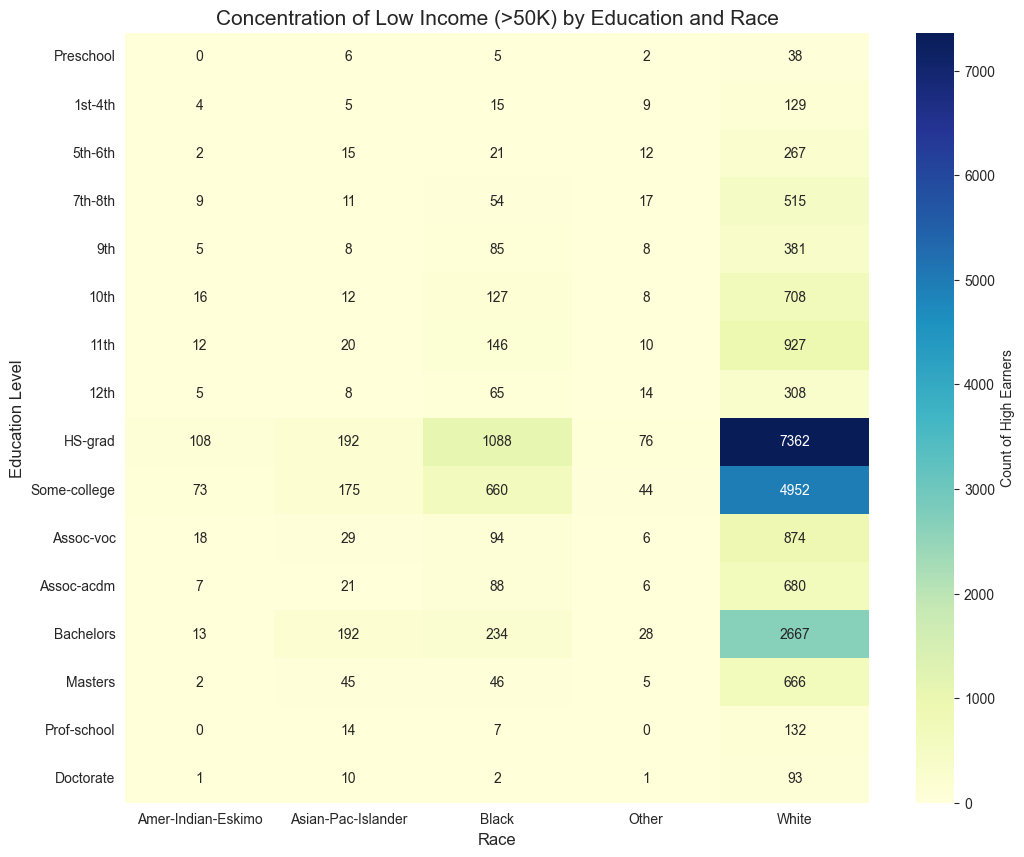

In [12]:
low_inc = df[df['income'] == '<=50K'].copy()
edu_order = df[['education', 'education-num']].drop_duplicates().sort_values('education-num')['education'].tolist()
pivot_table = low_inc.pivot_table(index='education', columns='race', values='age', aggfunc='count').fillna(0)
pivot_table = pivot_table.reindex(edu_order)
plt.figure(figsize=(12, 10))
sns.heatmap(pivot_table, annot=True, fmt=".0f", cmap="YlGnBu", cbar_kws={'label': 'Count of High Earners'})
plt.title('Concentration of Low Income (>50K) by Education and Race', fontsize=15)
plt.xlabel('Race', fontsize=12)
plt.ylabel('Education Level', fontsize=12)
plt.show()
# As we can see, mostly race doesnt affects education level.
# Also, from 2 last plots we can see that Individuals with better education have better chances to have better Income